# Olist E-Commerce Analysis
## Notebook 3 — Revenue Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA = 'C:/Users/loayi/OneDrive/Desktop/Workspace/olist-analysis/data/'

df = pd.read_csv(DATA + 'master.csv')
translations = pd.read_csv(DATA + 'product_category_name_translation.csv')
orders = pd.read_csv(DATA + 'olist_orders_dataset.csv')

df = pd.merge(df, translations, on='product_category_name', how='left')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
df = df.drop(columns=['order_purchase_timestamp'], errors='ignore')
df = pd.merge(df, orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')

print(df.shape)

(110197, 31)


## 1. Monthly Revenue Trend

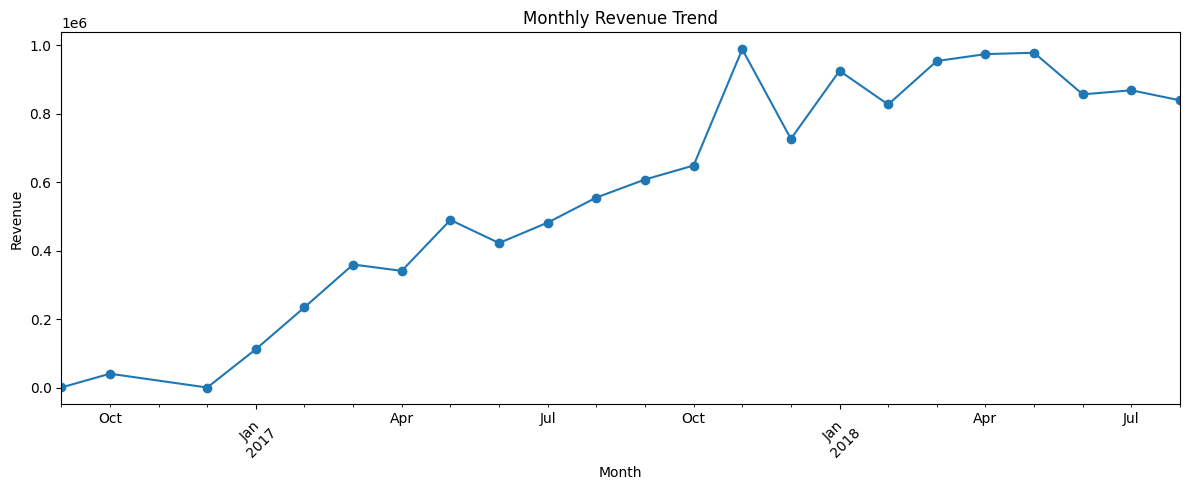

In [2]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
dick = df.groupby('month')['price'].sum()
dick.plot(figsize=(12, 5), marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Revenue grew consistently from late 2016 through 2018, with a notable spike in November 2017 (Black Friday). Monthly revenue roughly 8x'd from early 2017 to mid 2018.

## 2. Revenue by Product Category

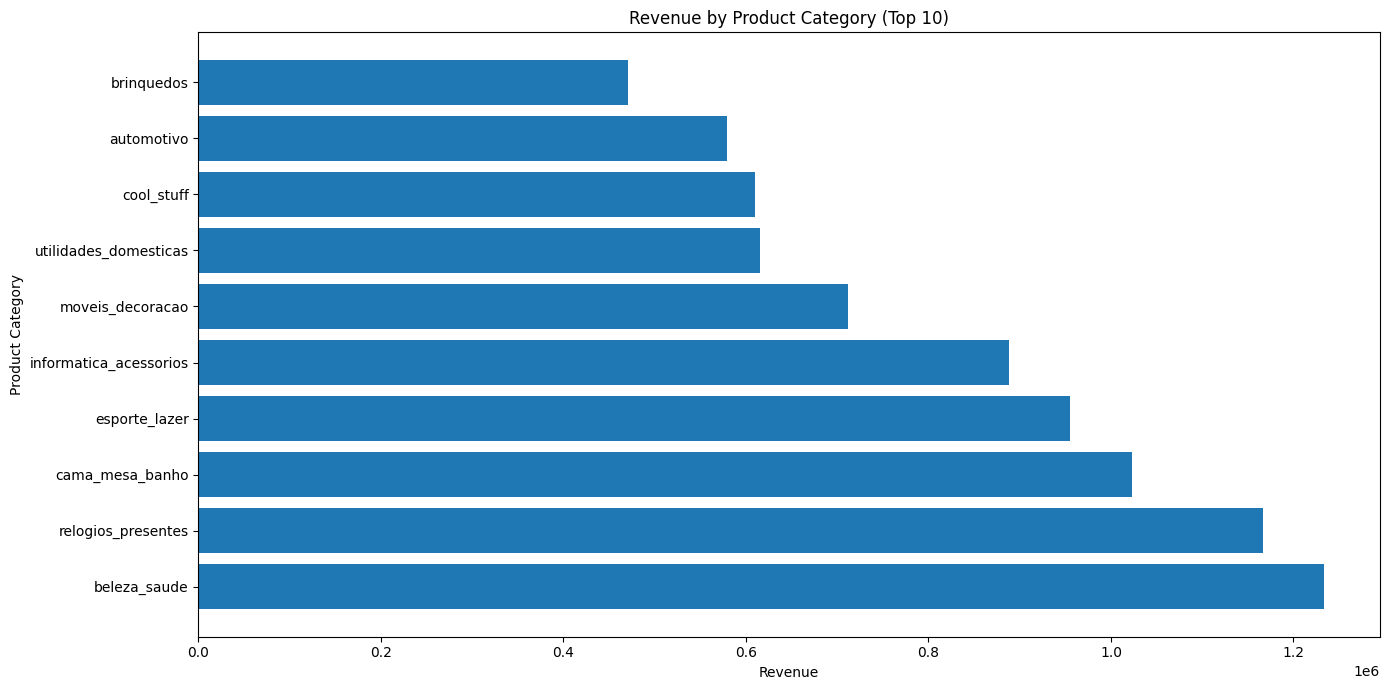

In [4]:
dick = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(14, 7))
plt.barh(dick.index, dick.values)
plt.title('Revenue by Product Category (Top 10)')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

**Insight:** Health & Beauty is the top revenue-generating category, followed by Watches and Bed/Bath. These three categories alone account for a significant portion of total platform revenue.

## 3. Revenue by State

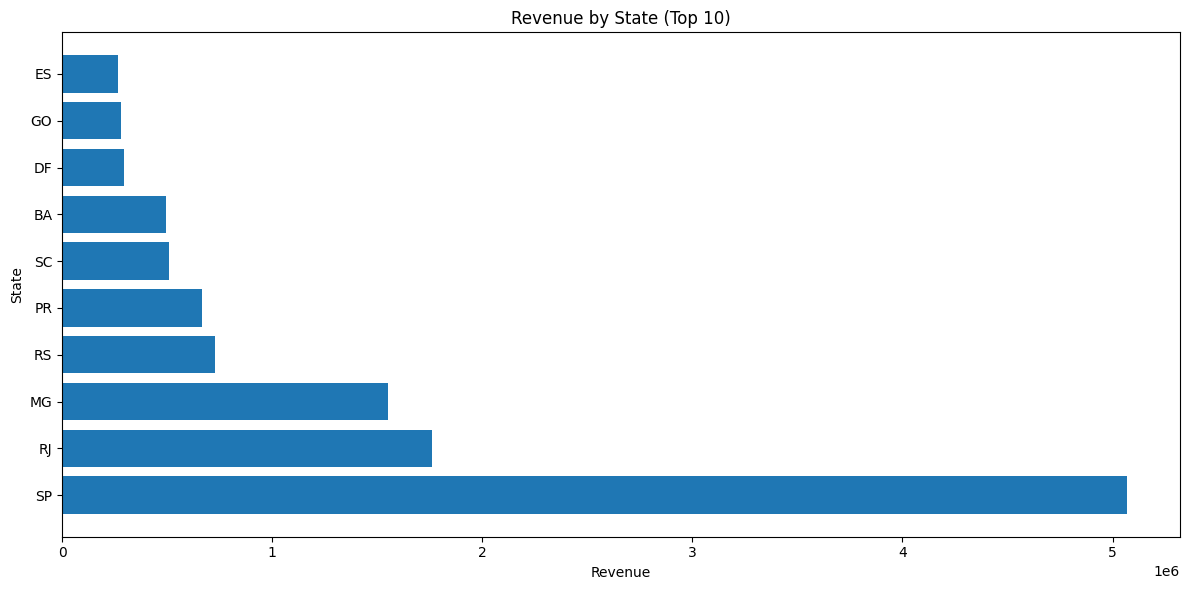

In [7]:
dick = df.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(dick.index, dick.values)
plt.title('Revenue by State (Top 10)')
plt.xlabel('Revenue')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Insight:** São Paulo dominates revenue by a large margin, reflecting its status as Brazil's largest economic hub.

## 4. Average Order Value

In [6]:
aov = df.groupby('order_id')['price'].sum().mean()
print(f'Average Order Value: ${aov:.2f}')

Average Order Value: $137.04


**Insight:** The average order value is ~$137, suggesting customers typically make mid-range purchases rather than bulk buying.

## 5. Top 10 Sellers by Revenue

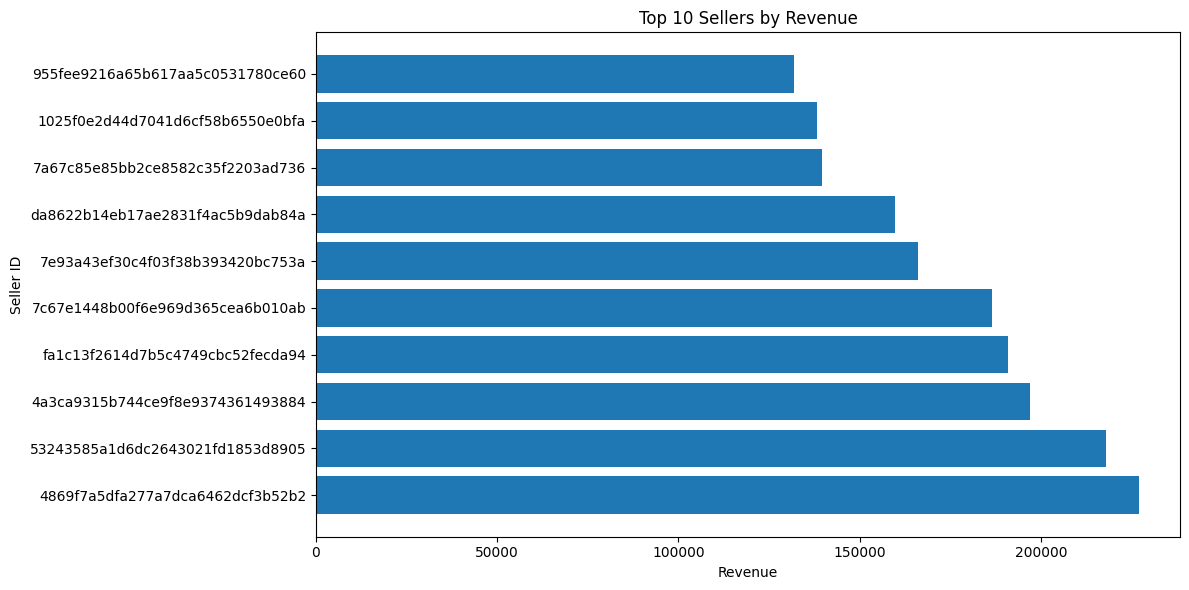

In [5]:
dick = df.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(dick.index, dick.values)
plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()

**Insight:** Revenue is distributed relatively evenly across top sellers — no single seller dominates the platform, indicating a healthy marketplace.